In [1]:
!pip uninstall -y captum
!pip install captum --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.7 MB/s eta 0:00:00


In [2]:
# !pip install "numpy<2.0"

In [3]:
import torch
import torch.nn as nn
from captum.attr import LayerIntegratedGradients
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import gc
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoModel
import os

In [4]:
MODEL_NAME = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GRAPH_PATH = '/kaggle/input/notebooks/srivarshitha16/gnn-pre-training'
pretrained_skill_embs = torch.tensor(np.load(os.path.join(GRAPH_PATH, 'skill_embeddings.npy')), dtype=torch.float32)

# 1. Pure Semantic (Transformer Only)
class PureSemantic(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.mlp = nn.Sequential(nn.Linear(self.transformer.config.hidden_size, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, *args):
        cls_emb = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.mlp(cls_emb).squeeze(-1)

# 2. Late Fusion (Text + Graph Concatenation)
class LateFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.skill_embs = nn.Embedding.from_pretrained(pretrained_skill_embs, freeze=False)
        self.mlp = nn.Sequential(nn.Linear(self.transformer.config.hidden_size + 256, 128), nn.ReLU(), nn.Linear(128, 1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, res_ids, jd_ids):
        cls_emb = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        r_g, j_g = [],[]
        for i in range(cls_emb.size(0)):
            r_g.append(self.skill_embs(torch.tensor(res_ids[i], device=device)).mean(dim=0) if res_ids[i] else torch.zeros(128, device=device))
            j_g.append(self.skill_embs(torch.tensor(jd_ids[i], device=device)).mean(dim=0) if jd_ids[i] else torch.zeros(128, device=device))
        return self.mlp(torch.cat([cls_emb, torch.stack(r_g), torch.stack(j_g)], dim=1)).squeeze(-1)

# 3. Cross-Attention
class CrossAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.skill_embs = nn.Embedding.from_pretrained(pretrained_skill_embs, freeze=False)
        self.proj = nn.Linear(128, self.transformer.config.hidden_size)
        self.attn = nn.MultiheadAttention(embed_dim=self.transformer.config.hidden_size, num_heads=4, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(self.transformer.config.hidden_size * 2, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, res_ids, jd_ids):
        seq = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        cls_emb = seq[:, 0, :]
        graph_seqs =[self.skill_embs(torch.tensor(res_ids[i]+jd_ids[i], device=device)) if (res_ids[i]+jd_ids[i]) else torch.zeros((1, 128), device=device) for i in range(seq.size(0))]
        proj_g = self.proj(pad_sequence(graph_seqs, batch_first=True))
        attn_out, _ = self.attn(query=seq, key=proj_g, value=proj_g)
        return self.mlp(torch.cat([cls_emb, attn_out[:, 0, :]], dim=1)).squeeze(-1)

# 4. Mixture of Experts (Our Proposed Solution)
class MoE_Fusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.skill_embs = nn.Embedding.from_pretrained(pretrained_skill_embs, freeze=False)
        dim = self.transformer.config.hidden_size
        self.text_expert = nn.Sequential(nn.Linear(dim, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.graph_expert = nn.Sequential(nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.gate = nn.Sequential(nn.Linear(dim + 256, 64), nn.ReLU(), nn.Linear(64, 2), nn.Softmax(dim=1))
    def forward(self, input_ids, attention_mask, res_ids, jd_ids):
        cls_emb = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        r_g, j_g = [],[]
        for i in range(cls_emb.size(0)):
            r_g.append(self.skill_embs(torch.tensor(res_ids[i], device=device)).mean(dim=0) if res_ids[i] else torch.zeros(128, device=device))
            j_g.append(self.skill_embs(torch.tensor(jd_ids[i], device=device)).mean(dim=0) if jd_ids[i] else torch.zeros(128, device=device))
        g_tensor = torch.cat([torch.stack(r_g), torch.stack(j_g)], dim=1)
        t_score = self.text_expert(cls_emb)
        g_score = self.graph_expert(g_tensor)
        gates = self.gate(torch.cat([cls_emb, g_tensor], dim=1))
        f_score = (gates[:, 0].unsqueeze(1) * t_score) + (gates[:, 1].unsqueeze(1) * g_score)
        return f_score.squeeze(-1), gates, t_score.squeeze(-1), g_score.squeeze(-1)

In [5]:
# ============================================================
# XAI CELL 1: Setup, IG Engine, Waterfall Plot, Faithfulness
# ============================================================
!pip install captum -q

from captum.attr import LayerIntegratedGradients
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Model registry — paths match where Cell 21 saved the .pth files
# ------------------------------------------------------------------
model_registry = {
    'Pure Semantic':   (PureSemantic,  '/kaggle/input/notebooks/srivarshitha16/experimenting-with-fusion-architectures/best_pure_semantic.pth'),
    'Late Fusion':     (LateFusion,    '/kaggle/input/notebooks/srivarshitha16/experimenting-with-fusion-architectures/best_late_fusion.pth'),
    'Cross-Attention': (CrossAttention,'/kaggle/input/notebooks/srivarshitha16/experimenting-with-fusion-architectures/best_cross_attention.pth'),
    'MoE':             (MoE_Fusion,    '/kaggle/input/notebooks/srivarshitha16/experimenting-with-fusion-architectures/best_moe_model.pth'),
}

def load_trained_model(model_class, path, device):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

# ------------------------------------------------------------------
# Safe forward wrapper: always returns a 1-D tensor of scores
# PureSemantic uses *args so it happily absorbs res_ids / jd_ids
# ------------------------------------------------------------------
def safe_forward(model, input_ids, attention_mask, res_ids, jd_ids):
    out = model(input_ids, attention_mask, res_ids, jd_ids)
    return out[0] if isinstance(out, tuple) else out   # shape: (B,)

# ------------------------------------------------------------------
# Integrated Gradients over the word-embedding layer
# ------------------------------------------------------------------
def get_text_attributions(model, input_ids, attention_mask, res_ids, jd_ids, device, n_steps=50):
    model.eval()
    pad_id   = tokenizer.pad_token_id or 0
    baseline = torch.full_like(input_ids, pad_id).to(device)

    # Captum internally expands the batch to (n_steps,) during interpolation.
    # We must repeat res_ids/jd_ids to always match the real batch size
    # being passed through, whatever it is at each internal step.
    def forward_fn(in_ids):
        bsz = in_ids.shape[0]  # will be n_steps (e.g. 50), not 1
        expanded_res = res_ids * bsz   # repeat the single sample bsz times
        expanded_jd  = jd_ids  * bsz
        return safe_forward(model, in_ids, attention_mask.expand(bsz, -1),
                            expanded_res, expanded_jd)

    lig  = LayerIntegratedGradients(forward_fn, model.transformer.embeddings.word_embeddings)
    attr = lig.attribute(inputs=input_ids, baselines=baseline,
                         target=None, n_steps=n_steps)

    scores = attr.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    return scores

# ------------------------------------------------------------------
# Waterfall bar chart — top-15 tokens by |attribution|
# ------------------------------------------------------------------
def plot_waterfall(token_scores, tokens, model_name):
    top_idx   = np.argsort(np.abs(token_scores))[::-1][:15]
    top_tok   = [tokens[i] for i in top_idx]
    top_score = [token_scores[i] for i in top_idx]
    colors    = ['steelblue' if x > 0 else 'tomato' for x in top_score]

    plt.figure(figsize=(10, 6))
    plt.barh(top_tok, top_score, color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Top-15 Token Attributions — {model_name}", fontweight='bold')
    plt.xlabel("Attribution Score (positive = pushes score UP)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# Faithfulness test: mask top-k tokens, measure score drop
# ------------------------------------------------------------------
def test_faithfulness(model, input_ids, attention_mask, res_ids, jd_ids,
                      token_scores, device, k=5):
    pad_id = tokenizer.pad_token_id or 0

    with torch.no_grad():
        orig = safe_forward(model, input_ids, attention_mask, res_ids, jd_ids).item()

    top_k = np.argsort(np.abs(token_scores))[-k:]
    masked = input_ids.clone()
    masked[0, top_k] = pad_id

    with torch.no_grad():
        new = safe_forward(model, masked, attention_mask, res_ids, jd_ids).item()

    print(f"  Original score          : {orig:.4f}")
    print(f"  Score after masking top-{k}: {new:.4f}")
    drop = orig - new
    is_faithful = drop > -1e-4  # treat anything above -0.0001 as faithful
    print(f"  Score drop              : {drop:.4f}  "
          f"({'faithful' if is_faithful else 'not faithful'})")

print("XAI helpers loaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contr

In [6]:
# ============================================================
# XAI CELL 1.5: Load data & build test_loader
# ============================================================
import ast, json, os
import pandas as pd
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

DATA_PATH = '/kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project'

#  Load test CSV 
test_df = pd.read_csv(os.path.join(DATA_PATH, 'test_clean.csv'))

def parse_skills(s):
    try: return ast.literal_eval(s)
    except: return []

test_df['extracted_skills_res'] = test_df['extracted_skills_res'].apply(parse_skills)
test_df['extracted_skills_jd']  = test_df['extracted_skills_jd'].apply(parse_skills)

#  Load skill vocab & map skills -> IDs 
with open(os.path.join(DATA_PATH, 'skill_vocab.json')) as f:
    skill_vocab = json.load(f)
skill_to_id = {s: i for i, s in enumerate(skill_vocab)}

def get_skill_ids(skills):
    return [skill_to_id[s] for s in skills if s in skill_to_id]

test_df['res_skill_ids'] = test_df['extracted_skills_res'].apply(get_skill_ids)
test_df['jd_skill_ids']  = test_df['extracted_skills_jd'].apply(get_skill_ids)

#  Tokenizer 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

#  Dataset & DataLoader 
class ResumeJDDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = tokenizer(str(row['resume_text']), str(row['smart_jd_text']),
                        max_length=512, padding='max_length',
                        truncation=True, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'res_skill_ids':  row['res_skill_ids'],
            'jd_skill_ids':   row['jd_skill_ids'],
            'target':         torch.tensor(row['score'], dtype=torch.float)
        }

def custom_collate(batch):
    return {
        'input_ids':      torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'res_skill_ids':  [x['res_skill_ids'] for x in batch],
        'jd_skill_ids':   [x['jd_skill_ids'] for x in batch],
        'target':         torch.stack([x['target'] for x in batch])
    }

test_loader = DataLoader(ResumeJDDataset(test_df), batch_size=16,
                         shuffle=False, collate_fn=custom_collate)

print(f"test_loader ready — {len(test_df)} samples, {len(test_loader)} batches")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

test_loader ready — 1759 samples, 110 batches



  Analysing: Pure Semantic


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing Integrated Gradients …

Faithfulness test (delete top-5 tokens):
  Original score          : 0.3526
  Score after masking top-5: 0.3526
  Score drop              : 0.0000  (faithful)

Generating waterfall plot …


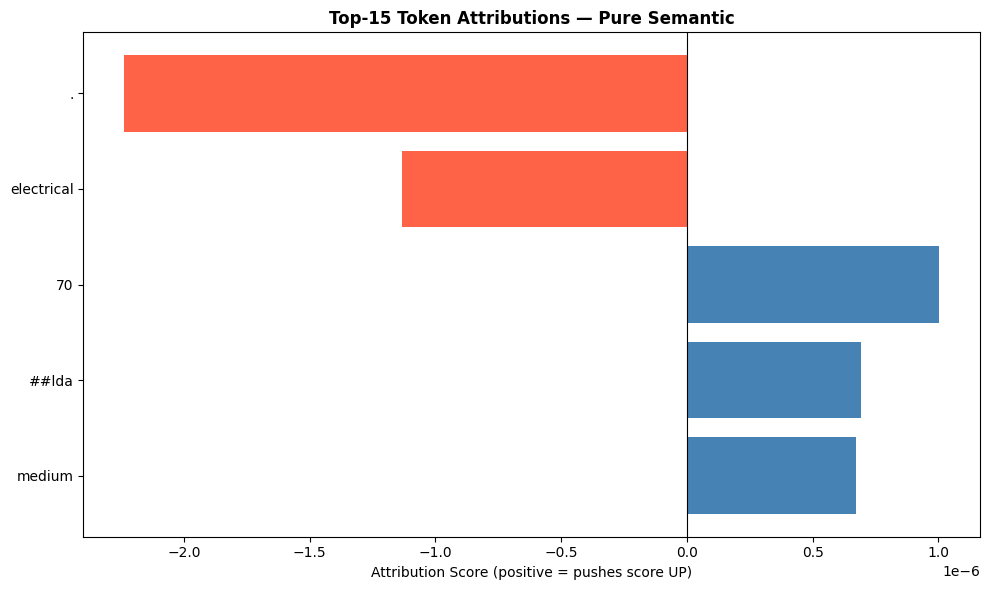


  Analysing: Late Fusion


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing Integrated Gradients …

Faithfulness test (delete top-5 tokens):
  Original score          : 0.3114
  Score after masking top-5: 0.2991
  Score drop              : 0.0124  (faithful)

Generating waterfall plot …


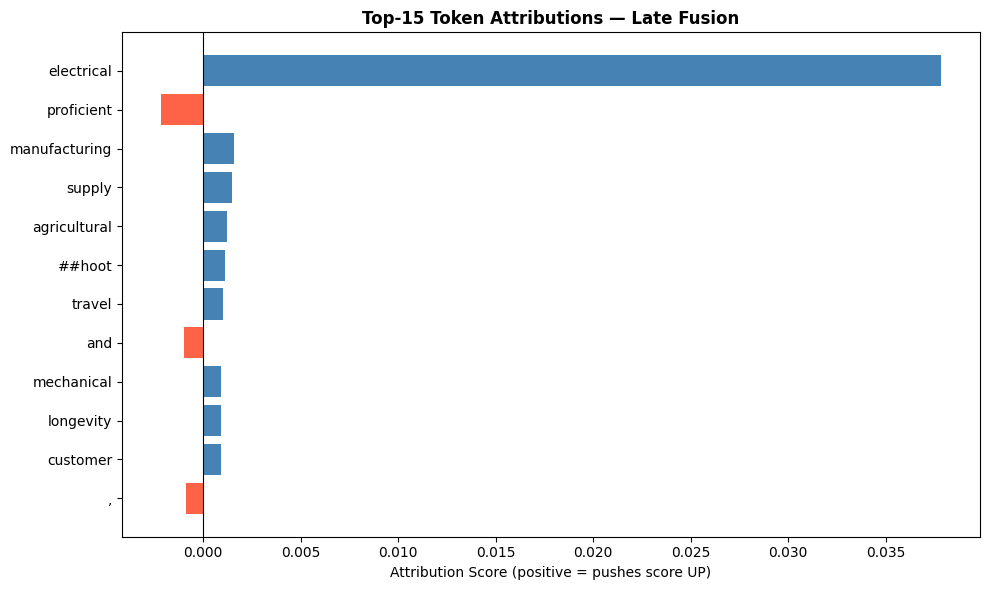


  Analysing: Cross-Attention


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing Integrated Gradients …

Faithfulness test (delete top-5 tokens):
  Original score          : 0.1396
  Score after masking top-5: 0.1385
  Score drop              : 0.0011  (faithful)

Generating waterfall plot …


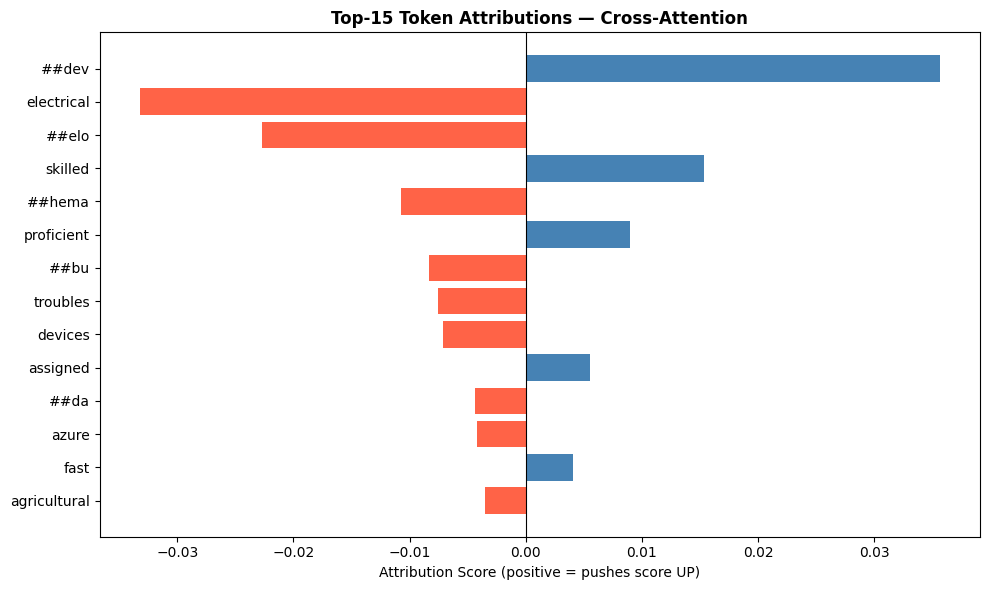


  Analysing: MoE


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing Integrated Gradients …

Faithfulness test (delete top-5 tokens):
  Original score          : 0.3144
  Score after masking top-5: 0.3144
  Score drop              : -0.0000  (faithful)

Generating waterfall plot …


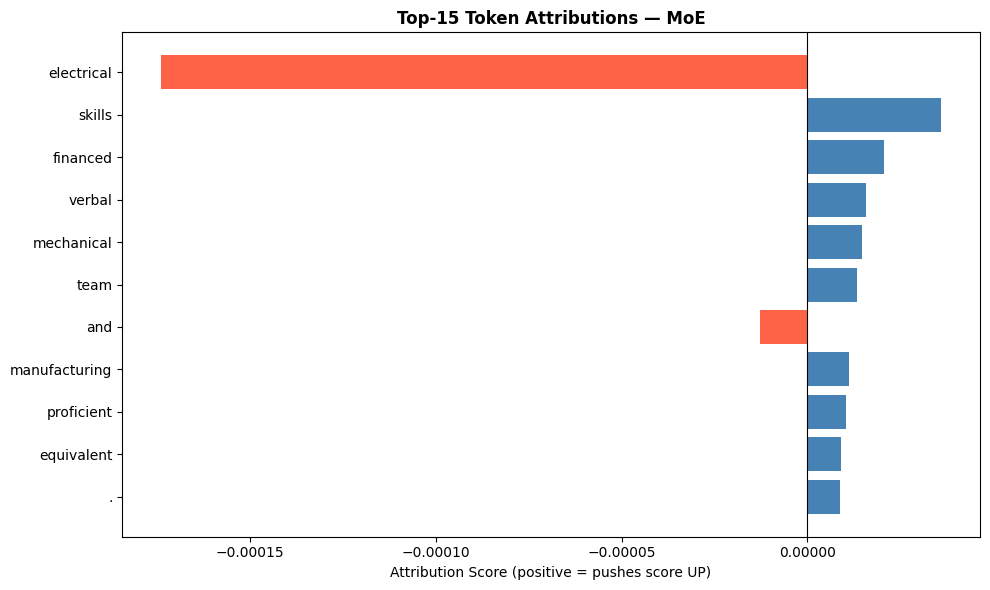


  MoE Gate weights  ->  Text: 0.194  |  Graph: 0.806
  Text expert score : 0.0569
  Graph expert score: 0.3765

  Graph Expert — Resume Skill Ablation:
  Skill                            Impact
  --------------------------------------
  sql server                     +0.0014  ██████
  software development           +0.0009  ████
  integration                    +0.0009  ████
  stored procedures              +0.0009  ████
  data pipelines                 +0.0008  ████
  devops                         +0.0008  ████
  agile methodologies            +0.0007  ███
  optimization                   +0.0006  ██
  oracle                         +0.0005  ██
  sdlc                           +0.0005  ██


In [7]:
# ============================================================
# XAI CELL 2: Run full IG analysis for every architecture
# ============================================================


def run_xai_analysis(model_name, test_loader, tokenizer, device, n_steps=50):
    print(f"\n{'='*55}")
    print(f"  Analysing: {model_name}")
    print(f"{'='*55}")

    #  Load saved model 
    cls, path = model_registry[model_name]
    model     = load_trained_model(cls, path, device)

    #  Pull one sample from the test set 
    batch      = next(iter(test_loader))
    input_ids  = batch['input_ids'][0:1].to(device)        # (1, seq_len)
    attn_mask  = batch['attention_mask'][0:1].to(device)   # (1, seq_len)
    res_ids    = [batch['res_skill_ids'][0]]                # list of lists
    jd_ids     = [batch['jd_skill_ids'][0]]

    #  Integrated Gradients ─
    print("Computing Integrated Gradients …")
    token_scores = get_text_attributions(model, input_ids, attn_mask,
                                         res_ids, jd_ids, device, n_steps)

    #  Decode tokens, strip padding / special tokens 
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    skip   = {'[PAD]', '[CLS]', '[SEP]'}
    valid  = [(i, t) for i, t in enumerate(tokens) if t not in skip]
    clean_idx    = [i for i, _ in valid]
    clean_tokens = [t for _, t in valid]
    clean_scores = token_scores[clean_idx]

    #  Faithfulness test ─
    print("\nFaithfulness test (delete top-5 tokens):")
    test_faithfulness(model, input_ids, attn_mask,
                      res_ids, jd_ids, token_scores, device, k=5)

    #  Waterfall plot 
    print("\nGenerating waterfall plot …")
    plot_waterfall(clean_scores, clean_tokens, model_name)

    #  MoE-specific: print gate weights + graph skill attribution 
    if model_name == 'MoE':
        with torch.no_grad():
            _, gates, t_sc, g_sc = model(input_ids, attn_mask, res_ids, jd_ids)
        print(f"\n  MoE Gate weights  ->  Text: {gates[0,0].item():.3f}  |  "
              f"Graph: {gates[0,1].item():.3f}")
        print(f"  Text expert score : {t_sc[0].item():.4f}")
        print(f"  Graph expert score: {g_sc[0].item():.4f}")

        #  Graph skill ablation (only meaningful if graph gate is dominant) 
        print("\n  Graph Expert — Resume Skill Ablation:")
        with torch.no_grad():
            baseline_score = safe_forward(model, input_ids, attn_mask, res_ids, jd_ids).item()

        skill_impacts = []
        for drop_idx in range(len(res_ids[0])):
            ablated_res = [res_ids[0][:drop_idx] + res_ids[0][drop_idx+1:]]
            with torch.no_grad():
                ablated_score = safe_forward(model, input_ids, attn_mask, ablated_res, jd_ids).item()
            skill_name = skill_vocab[res_ids[0][drop_idx]]   # skill_vocab must be loaded
            skill_impacts.append((baseline_score - ablated_score, skill_name))

        skill_impacts.sort(reverse=True)
        print(f"  {'Skill':<30} {'Impact':>8}")
        print(f"  {'-'*38}")
        for impact, name in skill_impacts[:10]:
            bar = '█' * int(abs(impact) * 5000)
            sign = '+' if impact >= 0 else '-'
            print(f"  {name:<30} {sign}{abs(impact):.4f}  {bar}")

#  Run for all 4 architectures ─
for name in model_registry:
    run_xai_analysis(name, test_loader, tokenizer, device)

In [8]:
# ============================================================
# Save XAI Results
# ============================================================
import os
output_dir = '/kaggle/working/xai_results'
os.makedirs(output_dir, exist_ok=True)

def run_and_save_xai(model_name, test_loader, tokenizer, device, n_steps=50):
    print(f"\n{'='*55}")
    print(f"  Saving XAI for: {model_name}")
    print(f"{'='*55}")

    cls, path = model_registry[model_name]
    model     = load_trained_model(cls, path, device)

    batch     = next(iter(test_loader))
    input_ids = batch['input_ids'][0:1].to(device)
    attn_mask = batch['attention_mask'][0:1].to(device)
    res_ids   = [batch['res_skill_ids'][0]]
    jd_ids    = [batch['jd_skill_ids'][0]]

    token_scores = get_text_attributions(model, input_ids, attn_mask,
                                         res_ids, jd_ids, device, n_steps)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    skip   = {'[PAD]', '[CLS]', '[SEP]'}
    valid  = [(i, t) for i, t in enumerate(tokens) if t not in skip]
    clean_idx    = [i for i, _ in valid]
    clean_tokens = [t for _, t in valid]
    clean_scores = token_scores[clean_idx]

    #  Save waterfall plot 
    top_idx   = np.argsort(np.abs(clean_scores))[::-1][:15]
    top_tok   = [clean_tokens[i] for i in top_idx]
    top_score = [clean_scores[i] for i in top_idx]
    colors    = ['steelblue' if x > 0 else 'tomato' for x in top_score]

    plt.figure(figsize=(10, 6))
    plt.barh(top_tok, top_score, color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Top-15 Token Attributions — {model_name}", fontweight='bold')
    plt.xlabel("Attribution Score (positive = pushes score UP)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    safe_name = model_name.replace(' ', '_').replace('-', '_')
    plot_path = os.path.join(output_dir, f"waterfall_{safe_name}.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Saved waterfall → {plot_path}")

    #  Save faithfulness + token scores to CSV 
    drop = orig = new = None
    pad_id = tokenizer.pad_token_id or 0
    with torch.no_grad():
        orig = safe_forward(model, input_ids, attn_mask, res_ids, jd_ids).item()
    top_k = np.argsort(np.abs(token_scores))[-5:]
    masked = input_ids.clone()
    masked[0, top_k] = pad_id
    with torch.no_grad():
        new = safe_forward(model, masked, attn_mask, res_ids, jd_ids).item()
    drop = orig - new

    token_df = pd.DataFrame({'token': clean_tokens, 'attribution': clean_scores})
    token_df['model'] = model_name
    csv_path = os.path.join(output_dir, f"token_scores_{safe_name}.csv")
    token_df.to_csv(csv_path, index=False)
    print(f"  Saved token scores → {csv_path}")

    #  Save faithfulness summary 
    faith_path = os.path.join(output_dir, f"faithfulness_{safe_name}.txt")
    with open(faith_path, 'w') as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Original score          : {orig:.4f}\n")
        f.write(f"Score after masking top-5: {new:.4f}\n")
        f.write(f"Score drop              : {drop:.4f}\n")
        f.write(f"Faithful                : {drop > -1e-4}\n")
    print(f"  Saved faithfulness  → {faith_path}")

    #  MoE: save gate weights + skill ablation to CSV 
    if model_name == 'MoE':
        with torch.no_grad():
            _, gates, t_sc, g_sc = model(input_ids, attn_mask, res_ids, jd_ids)

        skill_impacts = []
        with torch.no_grad():
            baseline_score = safe_forward(model, input_ids, attn_mask, res_ids, jd_ids).item()
        for drop_idx in range(len(res_ids[0])):
            ablated_res = [res_ids[0][:drop_idx] + res_ids[0][drop_idx+1:]]
            with torch.no_grad():
                ablated_score = safe_forward(model, input_ids, attn_mask, ablated_res, jd_ids).item()
            skill_impacts.append({
                'skill':        skill_vocab[res_ids[0][drop_idx]],
                'impact':       baseline_score - ablated_score,
                'gate_text':    gates[0, 0].item(),
                'gate_graph':   gates[0, 1].item(),
                'text_score':   t_sc[0].item(),
                'graph_score':  g_sc[0].item(),
            })

        moe_df = pd.DataFrame(skill_impacts).sort_values('impact', ascending=False)
        moe_path = os.path.join(output_dir, 'moe_skill_ablation.csv')
        moe_df.to_csv(moe_path, index=False)
        print(f"  Saved MoE ablation  → {moe_path}")

#  Run save for all 4 models ─
for name in model_registry:
    run_and_save_xai(name, test_loader, tokenizer, device)

print(f"\nAll XAI outputs saved to {output_dir}")


  Saving XAI for: Pure Semantic


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Saved waterfall → /kaggle/working/xai_results/waterfall_Pure_Semantic.png
  Saved token scores → /kaggle/working/xai_results/token_scores_Pure_Semantic.csv
  Saved faithfulness  → /kaggle/working/xai_results/faithfulness_Pure_Semantic.txt

  Saving XAI for: Late Fusion


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Saved waterfall → /kaggle/working/xai_results/waterfall_Cross_Attention.png
  Saved token scores → /kaggle/working/xai_results/token_scores_Cross_Attention.csv
  Saved faithfulness  → /kaggle/working/xai_results/faithfulness_Cross_Attention.txt

  Saving XAI for: MoE


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Saved waterfall → /kaggle/working/xai_results/waterfall_MoE.png
  Saved token scores → /kaggle/working/xai_results/token_scores_MoE.csv
  Saved faithfulness  → /kaggle/working/xai_results/faithfulness_MoE.txt
  Saved MoE ablation  → /kaggle/working/xai_results/moe_skill_ablation.csv

All XAI outputs saved to /kaggle/working/xai_results
